In [1]:
import os
import sys
sys.path.append(os.path.abspath('') + '/..')

In [2]:
from dataset_evaluation_utils import * 


import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')

# import plotly.offline as py
# pd.options.plotting.backend = "plotly"
# py.init_notebook_mode() # graphs charts inline (IPython).

a4_dims = (11.7, 8.27)

# paths

In [3]:
dataset_folderpath = '../datasets/goodreads/'

dataset_name = 'Goodreads'
filename = 'inter_dedup_coldstart_3stars_4x714k'

period=['2012-07', '2015-01']
sample = 'sample_'+str(period[0])+'_until_'+str(period[1])
dump_foldername ='goodreads_dump/'+'pos_rates_only/'+sample+'/'


# rule: what/which_data_set/sample_version/what/
images_path, output_path, heatmaps_path, diversity_graphpath, diversity_filepath = get_folderpaths(dump_foldername)

In [4]:
interactions_df = pd.read_csv(output_path+filename+'_interactions_df.csv', index_col=0)
interactions_df['date'] = interactions_df['date'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d'))
interactions_df.head()

,user_id,book_id,timestamp,date
205,8842281e1d1347389f2ab93d60773d4d,25019,1.420088e+09,2015-01-01
216,8842281e1d1347389f2ab93d60773d4d,1969280,1.414814e+09,2014-11-01
217,8842281e1d1347389f2ab93d60773d4d,17290220,1.414814e+09,2014-11-01
219,8842281e1d1347389f2ab93d60773d4d,6882,1.412136e+09,2014-10-01
220,8842281e1d1347389f2ab93d60773d4d,6954929,1.412136e+09,2014-10-01


In [5]:
interactions_df.columns = ['user_id','item_id','timestamp','date']

In [6]:
interactions_df.shape

(398129, 4)

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Load the dataset
# Replace 'dataset.csv' with your actual dataset file
# Ensure the dataset has columns: ['user_id', 'item_id', 'timestamp']
df = interactions_df.drop(columns=['date'])
df.head()

,user_id,item_id,timestamp
205,8842281e1d1347389f2ab93d60773d4d,25019,1.420088e+09
216,8842281e1d1347389f2ab93d60773d4d,1969280,1.414814e+09
217,8842281e1d1347389f2ab93d60773d4d,17290220,1.414814e+09
219,8842281e1d1347389f2ab93d60773d4d,6882,1.412136e+09
220,8842281e1d1347389f2ab93d60773d4d,6954929,1.412136e+09


In [8]:
# Step 1: Independence Check
# Correlation between consecutive interactions (temporal patterns)
df['time_diff'] = df['timestamp'].diff().fillna(0)
correlation = df['time_diff'].corr(df['item_id'].rank())  # Rank-based correlation
print(f"Time difference correlation with item ranks: {correlation}")

# Repeated interactions
repeated_interactions = df.duplicated(subset=['user_id', 'item_id']).sum()
print(f"Number of repeated interactions: {repeated_interactions}")

Time difference correlation with item ranks: 0.03534006482987451
Number of repeated interactions: 0


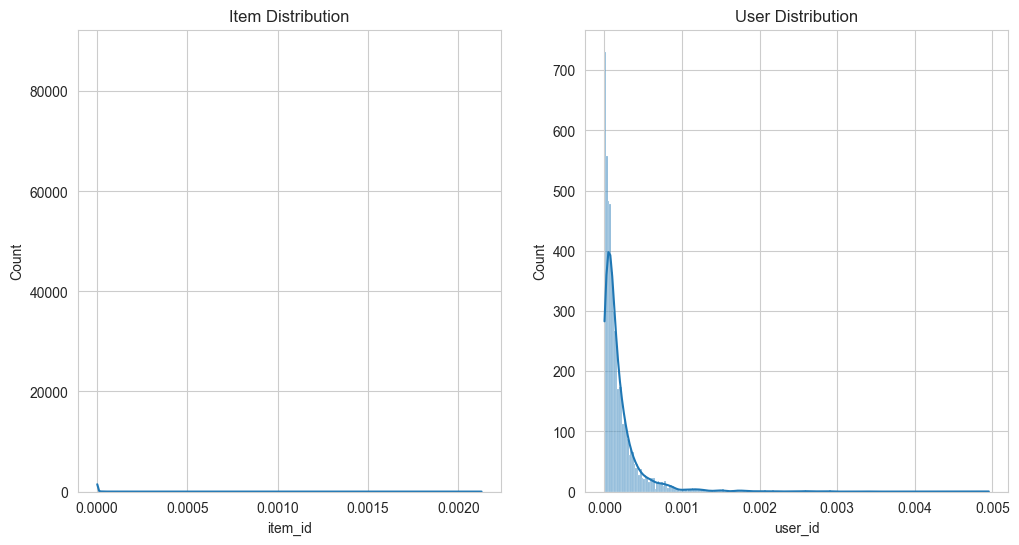

In [9]:
# Step 2: Identical Distribution Check
# Distribution of items across users
item_distribution = df['item_id'].value_counts(normalize=True)
user_distribution = df['user_id'].value_counts(normalize=True)


# Visualization of distributions
plt.figure(figsize=(12, 6))

# Item distribution
plt.subplot(1, 2, 1)
sns.histplot(item_distribution, kde=True)
plt.title("Item Distribution")

# User distribution
plt.subplot(1, 2, 2)
sns.histplot(user_distribution, kde=True)
plt.title("User Distribution")

plt.show()


In [10]:
print(df['user_id'].describe())
print(df['item_id'].describe())

count                               398129
unique                                5204
top       7b94fa5e0e2c4503b2a723cb2efc0c58
freq                                  1972
Name: user_id, dtype: object
count    3.981290e+05
mean     7.718814e+06
std      7.566935e+06
min      1.000000e+00
25%      1.400750e+05
50%      6.491887e+06
75%      1.554472e+07
max      3.604547e+07
Name: item_id, dtype: float64


In [11]:
print("Unique user IDs:", df['user_id'].nunique())
print("Unique item IDs:", df['item_id'].nunique())
print("Max user ID:", df['user_id'].max())
print("Max item ID:", df['item_id'].max())


Unique user IDs: 5204
Unique item IDs: 132352
Max user ID: fff917f04fe7bff3a6bf98c541d8324b
Max item ID: 36045474


In [15]:
df.reset_index(drop=True, inplace=True)

# print("Unique user IDs:", df['user_id'].nunique())
# print("Unique item IDs:", df['item_id'].nunique())
# print("Max user ID:", df['user_id'].max())
# print("Max item ID:", df['item_id'].max())


In [16]:
df.head()

,user_id,item_id,timestamp,time_diff
0,8842281e1d1347389f2ab93d60773d4d,25019,1.420088e+09,0.0
1,8842281e1d1347389f2ab93d60773d4d,1969280,1.414814e+09,-5274000.0
2,8842281e1d1347389f2ab93d60773d4d,17290220,1.414814e+09,0.0
3,8842281e1d1347389f2ab93d60773d4d,6882,1.412136e+09,-2678400.0
4,8842281e1d1347389f2ab93d60773d4d,6954929,1.412136e+09,0.0


# test the code is equivalent

In [17]:
pd.crosstab(df.loc[:10,'user_id'], df.loc[:10,'item_id'])

item_id,6882,25019,1969280,5577844,6954929,12961964,17290220,17855756,18176747,19816540,21792828
user_id,,,,,,,,,,,
8842281e1d1347389f2ab93d60773d4d,1,1,1,1,1,1,1,1,1,1,1


In [18]:
ij, tups = pd.factorize(list(zip(*map(df.loc[:10,['user_id', 'item_id']].get, df.loc[:10,['user_id', 'item_id']]))))
result = dict(zip(tups, np.bincount(ij)))
result

{('8842281e1d1347389f2ab93d60773d4d', 25019): 1,
 ('8842281e1d1347389f2ab93d60773d4d', 1969280): 1,
 ('8842281e1d1347389f2ab93d60773d4d', 17290220): 1,
 ('8842281e1d1347389f2ab93d60773d4d', 6882): 1,
 ('8842281e1d1347389f2ab93d60773d4d', 6954929): 1,
 ('8842281e1d1347389f2ab93d60773d4d', 18176747): 1,
 ('8842281e1d1347389f2ab93d60773d4d', 5577844): 1,
 ('8842281e1d1347389f2ab93d60773d4d', 21792828): 1,
 ('8842281e1d1347389f2ab93d60773d4d', 19816540): 1,
 ('8842281e1d1347389f2ab93d60773d4d', 17855756): 1,
 ('8842281e1d1347389f2ab93d60773d4d', 12961964): 1}

In [19]:
pd.Series(result).unstack(fill_value=0)

,6882,25019,1969280,5577844,6954929,12961964,17290220,17855756,18176747,19816540,21792828
8842281e1d1347389f2ab93d60773d4d,1,1,1,1,1,1,1,1,1,1,1


In [20]:
# np.array(list(result.items()))

In [21]:
# np.array([(key[0], key[1], value) for key, value in result.items()])

In [22]:
# np.array(list(result.values()))

In [23]:
rows = sorted(set(key[0] for key in result.keys()))  # ['A', 'B', 'C']
cols = sorted(set(key[1] for key in result.keys()))  # ['1', '2', '3', '4']

# Create an empty array
r = np.zeros((len(rows), len(cols)))

# Fill the array with data
for (row_label, col_label), value in result.items():
    row_idx = rows.index(row_label)
    col_idx = cols.index(col_label)
    r[row_idx, col_idx] = value

print(r)

[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


it does!!!

In [24]:
ij, tups = pd.factorize(list(zip(*map(df.loc[:,['user_id', 'item_id']].get, df.loc[:,['user_id', 'item_id']]))))
result = dict(zip(tups, np.bincount(ij)))
# result

In [25]:
rows = sorted(set(key[0] for key in result.keys()))  # ['A', 'B', 'C']
cols = sorted(set(key[1] for key in result.keys()))  # ['1', '2', '3', '4']

# Create an empty array
obs = np.zeros((len(rows), len(cols)))

# Fill the array with data
for (row_label, col_label), value in result.items():
    row_idx = rows.index(row_label)
    col_idx = cols.index(col_label)
    obs[row_idx, col_idx] = value

In [31]:
# pd.Series(result).unstack(fill_value=0) # pandas is the problem

In [26]:
# Chi-square test to check uniformity
p_item = -1
_, p_item, _, _ = chi2_contingency(obs)
print(f"Chi-square test p-value for item distribution: {p_item:.4f} (low value = non-uniform)")


Chi-square test p-value for item distribution: 1.0000 (low value = non-uniform)


In [27]:
# Step 3: IID Conditions Summary
print("\nIID Conditions Summary:")
if abs(correlation) < 0.1:
    print("1. Independence: PASSES (No strong temporal patterns)")
else:
    print("1. Independence: FAILS (Temporal patterns exist)")

if p_item > 0.05:
    print("2. Identical Distribution: PASSES (Uniform distribution of items/users)")
else:
    print("2. Identical Distribution: FAILS (Non-uniform distribution detected)")

if repeated_interactions == 0:
    print("3. Independence: PASSES (No repeated user-item interactions)")
else:
    print(f"3. Independence: FAILS ({repeated_interactions} repeated interactions detected)")


IID Conditions Summary:
1. Independence: PASSES (No strong temporal patterns)
2. Identical Distribution: PASSES (Uniform distribution of items/users)
3. Independence: PASSES (No repeated user-item interactions)


#########################################################################################################
# Original Code from chatGPT
* prompt "write the code to verify if the user-items interactions dataset fits the i.i.d. conditions
* on 09 Dec 2024
* OpenAI's GPT-4 model


recommended

Python 3.7 or later

pandas >= 1.0.0

numpy >= 1.18.0

seaborn >= 0.11.0

matplotlib >= 3.1.0

scipy >= 1.4.0

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Load the dataset
# Replace 'dataset.csv' with your actual dataset file
# Ensure the dataset has columns: ['user_id', 'item_id', 'timestamp']
df = pd.read_csv('dataset.csv')

# Step 1: Independence Check
# Correlation between consecutive interactions (temporal patterns)
df['time_diff'] = df['timestamp'].diff().fillna(0)
correlation = df['time_diff'].corr(df['item_id'].rank())  # Rank-based correlation
print(f"Time difference correlation with item ranks: {correlation}")

# Repeated interactions
repeated_interactions = df.duplicated(subset=['user_id', 'item_id']).sum()
print(f"Number of repeated interactions: {repeated_interactions}")

# Step 2: Identical Distribution Check
# Distribution of items across users
item_distribution = df['item_id'].value_counts(normalize=True)
user_distribution = df['user_id'].value_counts(normalize=True)

# Chi-square test to check uniformity
_, p_item, _, _ = chi2_contingency(pd.crosstab(df['user_id'], df['item_id']))
print(f"Chi-square test p-value for item distribution: {p_item:.4f} (low value = non-uniform)")

# Visualization of distributions
plt.figure(figsize=(12, 6))

# Item distribution
plt.subplot(1, 2, 1)
sns.histplot(item_distribution, kde=True)
plt.title("Item Distribution")

# User distribution
plt.subplot(1, 2, 2)
sns.histplot(user_distribution, kde=True)
plt.title("User Distribution")

plt.show()

# Step 3: IID Conditions Summary
print("\nIID Conditions Summary:")
if abs(correlation) < 0.1:
    print("1. Independence: PASSES (No strong temporal patterns)")
else:
    print("1. Independence: FAILS (Temporal patterns exist)")

if p_item > 0.05:
    print("2. Identical Distribution: PASSES (Uniform distribution of items/users)")
else:
    print("2. Identical Distribution: FAILS (Non-uniform distribution detected)")

if repeated_interactions == 0:
    print("3. Independence: PASSES (No repeated user-item interactions)")
else:
    print(f"3. Independence: FAILS ({repeated_interactions} repeated interactions detected)")
